In [1]:
%load_ext autoreload
%autoreload 2

In [380]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy import linalg as la

from jax.numpy import einsum

# for coloring lines
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import blochK
import blochK.observable as observable
from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import extent
from blochK.plotting.publication import (
    paper_style,
    paper_style_small,
    revtex_textwidth,
    revtex_columnwidth,
    set_size,
)
from blochK.observable import conductivity_orbital_resolved

from alter_surf.hamiltonian_CuMnAs import H_3D_fct, H_slab_fct
from alter_surf.hamiltonian_DLKK import (
    create_H_DLKK_3D,
    create_H_DLKK_3D_MF,
    create_H_DLKK_true3D,
)

import plot_funcs as pf

import sys, os


from alter_surf.utils3D import projector2layer

import pickle

matplotlib.rcParams.update(
    {
        "font.size": 7,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)
aps_figwidth = 6.9
aps_halfwidth = 3.4

define the three models


In [14]:
# DLKK Model
dlkk_params = dict(delta=1, tp=0.3, tz=1, PBC=False, mAF=3, mu=3.1)
DLKK_2D = create_H_DLKK_3D({"len_z": 30} | dlkk_params)
DLKK_2D.add_suboperator("proj", np.eye(DLKK_2D.n_orbitals))
DLKK_3D = create_H_DLKK_true3D(dlkk_params)

# Drumhead Model
drumhead_params = dict(t=0.4, tz=1.0, Delta0=0.6, Delta1=0.6, Delta3=0.6, mu=0.1)
Drumhead_2D = pf.slab_ham({"len_z": 31} | drumhead_params)
Drumhead_3D = blochK.Hamiltonian3D(
    H_3D_fct, param=drumhead_params, basis=["spin", "z-layer", "sublattice"]
)
Drumhead_3D.add_operator("spin", np.array([1, 1, 1, 1, -1, -1, -1, -1]))

# Weyl Model
weyl_params = dict(t=0.4, tz=1.0, Delta0=0.6, Delta1=0.6, Delta3=0.6, mu=0.1, dtpp=0.2)
Weyl_2D = pf.slab_ham({"len_z": 31} | weyl_params)
Weyl_3D = blochK.Hamiltonian3D(
    H_3D_fct, param=weyl_params, basis=["spin", "z-layer", "sublattice"]
)
Weyl_3D.add_operator("spin", np.array([1, 1, 1, 1, -1, -1, -1, -1]))


models_2D = [DLKK_2D, Drumhead_2D, Weyl_2D]
models_3D = [DLKK_3D, Drumhead_3D, Weyl_3D]
model_names = ["DLKK", "Drumhead", "Weyl"]

(124, 128) 124
(124, 128) 124


In [115]:
# define spectral paths
n_k_2d_path = 100

dlkk_points = np.array([[1, 1], [0, 1], [0, 0], [1, 0], [1, 1], [0, 0]])
dlkk_labels = [r"M", r"Y", r"$\Gamma$", r"X", r"M", r"$\Gamma$"]
dlkk_path = pf.make_path(dlkk_points, n_k_2d_path)
dkll_path_positions = np.linspace(0, len(dlkk_path), len(dlkk_labels)).astype(int)

drum_weyl_points = np.array([[0, 1], [0, 0], [1, 0], [0, 1], [1, 1], [0, 0]])
drum_weyl_labels = [r"Y", r"$\Gamma$", r"X", r"Y", r"M", r"$\Gamma$"]
drum_weyl_path = pf.make_path(drum_weyl_points, n_k_2d_path)
drum_weyl_path_positions = np.linspace(
    0, len(drum_weyl_path), len(drum_weyl_labels)
).astype(int)

paths = [dlkk_path, drum_weyl_path, drum_weyl_path]
path_labels = [dlkk_labels, drum_weyl_labels, drum_weyl_labels]
path_positions = [
    dkll_path_positions,
    drum_weyl_path_positions,
    drum_weyl_path_positions,
]

# define 2d slice k grids
spillover = 0.25
n_k_grid = 101
k_slice = np.linspace(
    -np.pi * (1 + spillover), np.pi * (1 + spillover), n_k_grid, endpoint=False
)
KX_slice, KY_slice = np.meshgrid(k_slice, k_slice)

In [116]:
# solve paths
energies_path = []
states_path = []

for model, path in zip(models_2D, paths):
    energies, states = model.diagonalize(*path.T)
    energies_path.append(energies)
    states_path.append(states)

# solve 2D grids
energies_grid = []
states_grid = []

for model in models_2D:
    energies, states = model.diagonalize(KX_slice, KY_slice)
    energies_grid.append(energies)
    states_grid.append(states)

In [117]:
from tqdm import tqdm

# make spectral walk functions
eta = 5e-2

spec_e_vals = []
spec_boundary_path = []
spec_bulk_path = []

for model, states, energies in zip(tqdm(models_2D), states_path, energies_path):

    e_vals = np.linspace(np.min(energies), np.max(energies), 200)
    specs_boundary_walk = pf.make_spectral_functions(
        model, [0], states, energies, e_vals, eta
    )
    specs_bulk_walk = pf.make_spectral_functions(
        model, [model.param["len_z"] // 2], states, energies, e_vals, eta
    )

    colors_bulk_walk, colors_boundary_walk = pf.normalize_and_find_colours(
        specs_bulk_walk, specs_boundary_walk, 0.7
    )
    spec_e_vals.append(e_vals)
    spec_boundary_path.append(colors_boundary_walk)
    spec_bulk_path.append(colors_bulk_walk)

del specs_bulk_walk, specs_boundary_walk

100%|██████████| 3/3 [01:29<00:00, 29.93s/it]


In [22]:
# make slice spectral functions

fermi_level = np.array([0])
eta = 5e-2

spec_boundary_grid = []
spec_bulk_grid = []

for model, states, energies in zip(tqdm(models_2D), states_grid, energies_grid):
    specs_boundary_slice = pf.make_spectral_functions(
        model, [0], states, energies, fermi_level, eta
    )
    specs_bulk_slice = pf.make_spectral_functions(
        model, [model.param["len_z"] // 2], states, energies, fermi_level, eta
    )
    colors_bulk_slice, colors_boundary_slice = pf.normalize_and_find_colours(
        specs_bulk_slice, specs_boundary_slice, 0.5
    )
    spec_boundary_grid.append(colors_boundary_slice)
    spec_bulk_grid.append(colors_bulk_slice)

del specs_bulk_slice, specs_boundary_slice

100%|██████████| 3/3 [00:26<00:00,  8.96s/it]


In [25]:
# make conductivities

from alter_surf.utils_DLKK import get_conductivity_layer_resolved as gcl_dlkk
from alter_surf.utils_CuMnAs import get_conductivity_layer_resolved as gcl_drum_weyl

gcl = [gcl_dlkk, gcl_drum_weyl, gcl_drum_weyl]

layers = []
conds = []
spin_conds = []

for model, g in zip(tqdm(models_2D), gcl):
    l, c, s = g(model, Lk=50)
    layers.append(l)
    conds.append(c)
    spin_conds.append(s)

del l, c, s, gcl

In [26]:
# make 3d band structures
path_3d = np.array(
    [
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 0],
        [0, 1, 0],
        [1, 1, 0],
        [1, 1, 1],
        [0, 1, 0],
        [0, 0, 1],
    ]
)
k_walk_3d = (
    np.concatenate(
        [
            np.linspace(path_3d[i], path_3d[i + 1], n_k_2d_path, endpoint=False)
            for i in range(len(path_3d) - 1)
        ]
    )
    * np.pi
)
labels_3d = [r"Y", r"X", r"$\Gamma$", r"Y", r"M", r"R", r"Y", r"Z"]
label_positions_3d = np.linspace(0, len(k_walk_3d), len(labels_3d)).astype(int)

es_3d = []
for model in models_3D:
    e_vals, _ = model.diagonalize(*k_walk_3d.T)
    es_3d.append(e_vals)

del e_vals

In [408]:
# collate all results

models = {"models_2D": models_2D, "models_3D": models_3D}

# spectral walks
spec_walks = {
    "paths": paths,
    "path_labels": path_labels,
    "path_positions": path_positions,
    "spec_e_vals": spec_e_vals,
    "spec_boundary_path": spec_boundary_path,
    "spec_bulk_path": spec_bulk_path,
}

# spectral grids
spec_grids = {
    "KX_slice": KX_slice,
    "KY_slice": KY_slice,
    "spec_boundary_grid": spec_boundary_grid,
    "spec_bulk_grid": spec_bulk_grid,
}

# conductivities
conductivities = {"layers": layers, "conds": conds, "spin_conds": spin_conds}

# 3d band structures
band_structures_3d = {
    "k_walk_3d": k_walk_3d,
    "labels_3d": labels_3d,
    "label_positions_3d": label_positions_3d,
    "es_3d": es_3d,
}

# save all results
with open("figure_data_round_2.pkl", "wb") as f:
    pickle.dump(
        {
            "models": models,
            "spec_walks": spec_walks,
            "spec_grids": spec_grids,
            "conductivities": conductivities,
            "band_structures_3d": band_structures_3d,
        },
        f,
    )

In [150]:
# load all results

with open("figure_data_round_2.pkl", "rb") as f:
    r = pickle.load(f)
    models = r["models"]
    spec_walks = r["spec_walks"]
    spec_grids = r["spec_grids"]
    conductivities = r["conductivities"]
    band_structures_3d = r["band_structures_3d"]

/var/folders/v4/z7wcc4gj6clczcj6vr8b9dvw0000gn/T/ipykernel_57289/1094692460.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


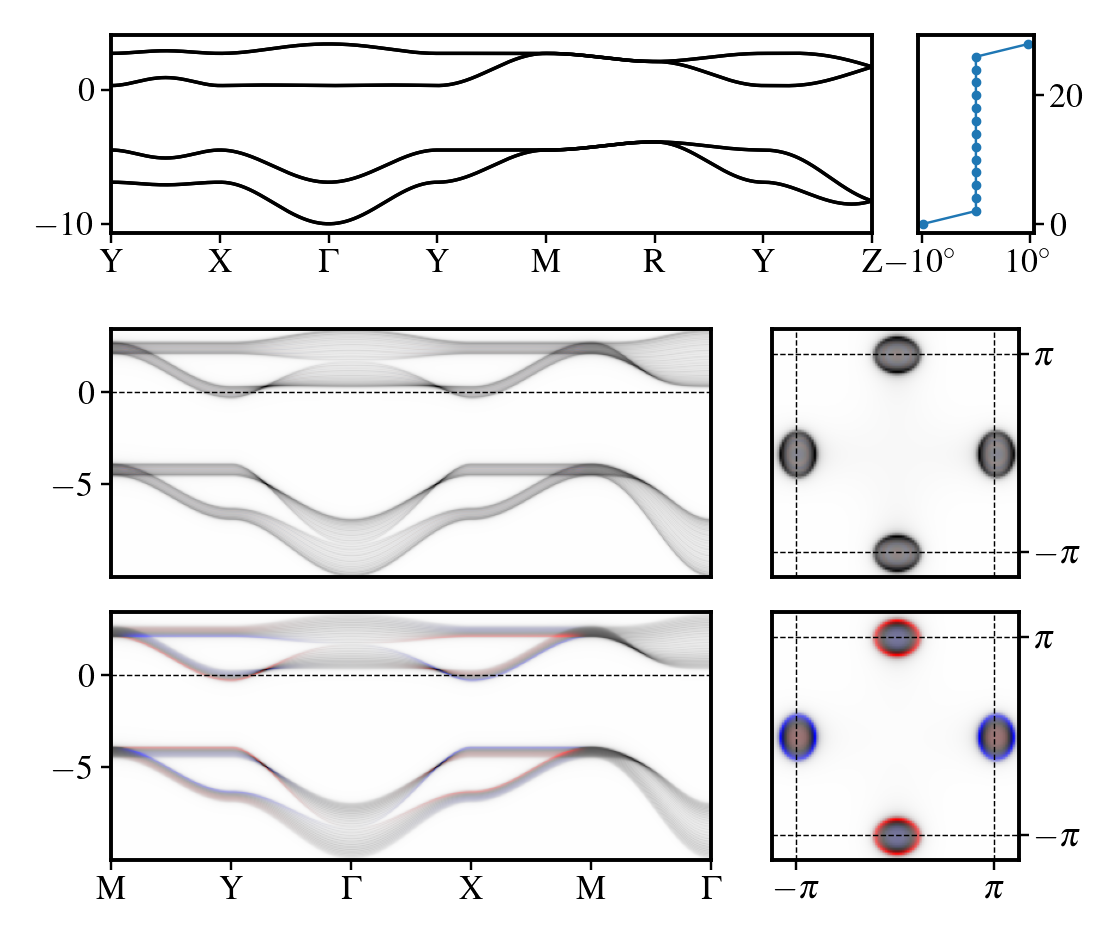

In [392]:
subplot_arrangement = """aaaaab
    ......
    ccccdd
    eeeeff"""


fig = plt.figure(figsize=(aps_halfwidth, aps_halfwidth * 0.9), dpi=350)
axd = fig.subplot_mosaic(
    subplot_arrangement,
    gridspec_kw={"wspace": 0.4, "hspace": 0.2},
    height_ratios=[0.8, 0.1, 1, 1],
)

# 3d band structure
axd["a"].plot(band_structures_3d["es_3d"][0].T, color="k", lw=0.7)
axd["a"].set_xlim(0, len(band_structures_3d["es_3d"][0].T))
axd["a"].set_xticks(
    band_structures_3d["label_positions_3d"], band_structures_3d["labels_3d"]
)

# spin splitter
c_u = conductivities["spin_conds"][0][:, 0, 0]
c_d = conductivities["conds"][0][:, 0, 0]
spin_splitter = 2 * np.arctan(c_u / c_d) * 180 / np.pi


axd["b"].plot(
    spin_splitter, conductivities["layers"][0], "o-", markersize=1, linewidth=0.5
)
axd["b"].tick_params(
    left=False,
    labelleft=False,
    right=True,
    labelright=True,
)
max_split = int(np.round(np.max(spin_splitter)))
axd["b"].set_xticks([-max_split, max_split])
axd["b"].set_xticklabels([f"$-{max_split}^\\circ$", f"${max_split}^\\circ$"])


# bulk path
axd["c"].imshow(
    spec_walks["spec_bulk_path"][0],
    extent=(
        0,
        len(spec_walks["paths"][0]),
        spec_walks["spec_e_vals"][0][0],
        spec_walks["spec_e_vals"][0][-1],
    ),
    aspect="auto",
    origin="lower",
)
axd["c"].tick_params(
    bottom=False,
    labelbottom=False,
)

# boundary path
axd["e"].imshow(
    spec_walks["spec_boundary_path"][0],
    extent=(
        0,
        len(spec_walks["paths"][0]),
        spec_walks["spec_e_vals"][0][0],
        spec_walks["spec_e_vals"][0][-1],
    ),
    aspect="auto",
    origin="lower",
)
axd["e"].set_xticks(spec_walks["path_positions"][0], spec_walks["path_labels"][0])


# bulk grid
axd["d"].imshow(
    np.swapaxes(spec_grids["spec_bulk_grid"][0], 0, 1),
    extent=(
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
    ),
)
axd["d"].tick_params(
    bottom=False,
    labelbottom=False,
    left=False,
    labelleft=False,
    right=True,
    labelright=True,
)

axd["d"].set_yticks([-np.pi, np.pi])
axd["d"].set_yticklabels(["$-\\pi$", "$\\pi$"])

# boundary grid
axd["f"].imshow(
    np.swapaxes(spec_grids["spec_boundary_grid"][0], 0, 1),
    extent=(
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
    ),
)
axd["f"].tick_params(
    bottom=True,
    labelbottom=True,
    left=False,
    labelleft=False,
    right=True,
    labelright=True,
)
axd["f"].set_xticks([-np.pi, np.pi])
axd["f"].set_yticks([-np.pi, np.pi])
axd["f"].set_yticklabels(["$-\\pi$", "$\\pi$"])
axd["f"].set_xticklabels(["$-\\pi$", "$\\pi$"])

# for a in (axd["a"], axd["c"], axd["e"]):
#     a.set_ylabel("Energy")

# axd["b"].set_ylabel("Layer")
# axd["b"].set_xlabel(r"$\alpha$")

for a in (axd["c"], axd["e"]):
    a.axhline(0, color="k", ls="--", lw=0.3)

for a in (axd["d"], axd["f"]):
    a.axhline(-np.pi, color="k", ls="--", lw=0.3)
    a.axhline(np.pi, color="k", ls="--", lw=0.3)
    a.axvline(-np.pi, color="k", ls="--", lw=0.3)
    a.axvline(np.pi, color="k", ls="--", lw=0.3)

for a in axd:

    axd[a].tick_params(length=2, width=0.5, pad=1.3)
plt.tight_layout()
plt.savefig("fig_2.png", dpi=350, bbox_inches="tight", transparent=True)

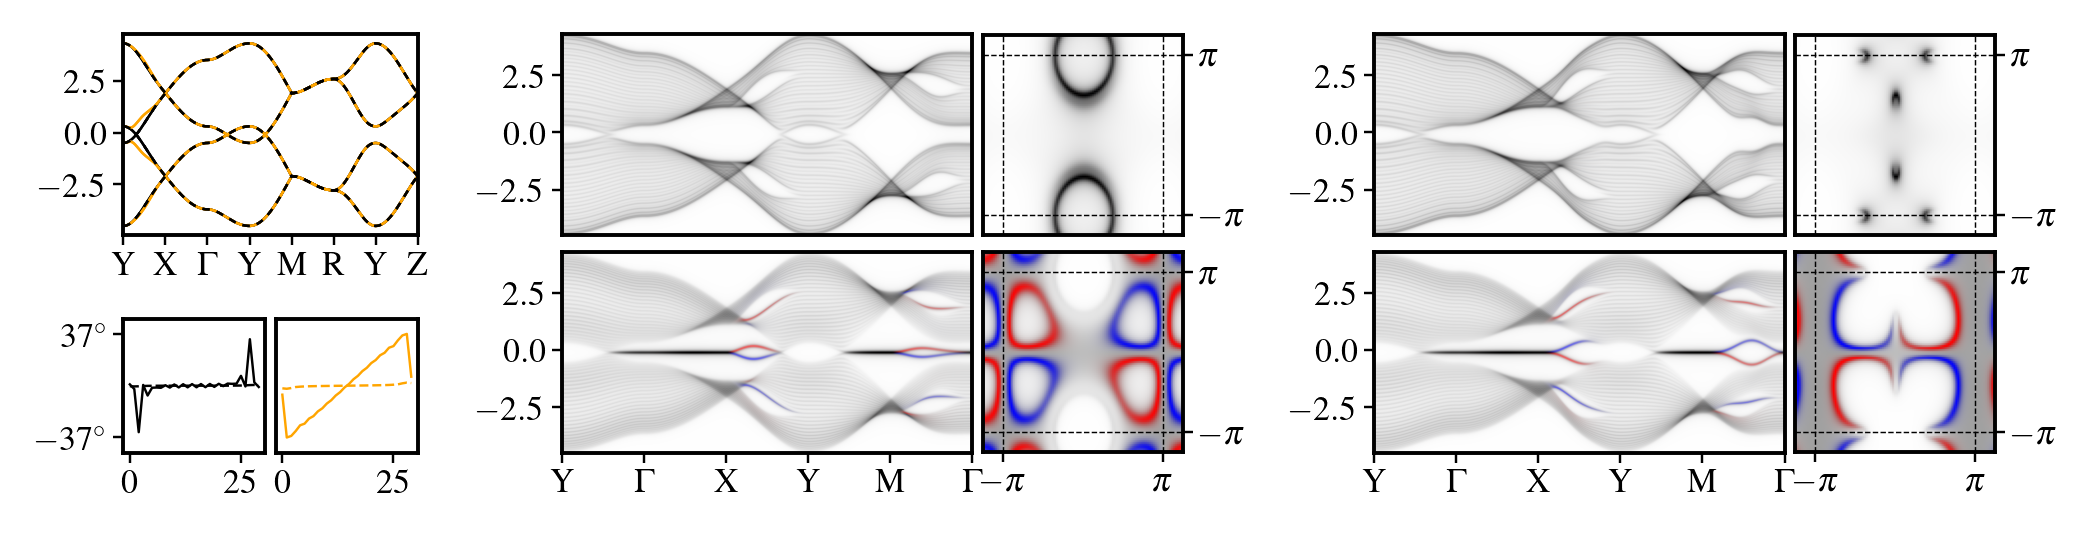

In [ ]:
subplot_arrangement = """
aa.ccccdd.eeeeff
aa.ccccdd.eeeeff
aa.ccccdd.eeeeff
................
...hhhhii.jjjjkk
bg.hhhhii.jjjjkk
bg.hhhhii.jjjjkk
"""
gap1 = 1.3
gap2 = 1.8

fig = plt.figure(figsize=(aps_figwidth, aps_figwidth * 0.225), dpi=350)
axd = fig.subplot_mosaic(
    subplot_arrangement,
    gridspec_kw={"wspace": 0.1, "hspace": 0.0},
    width_ratios=[1.5, 1.5] + [gap1] + [1] * 6 + [gap2] + [1] * 6,
    height_ratios=[1, 1, 1, 1 / 4, 1, 1, 1],
)


################### 3d band structures ###################

axd["a"].plot(band_structures_3d["es_3d"][1].T, color="k", lw=0.5)
axd["a"].plot(band_structures_3d["es_3d"][2].T, color="orange", lw=0.5)
axd["a"].plot(
    band_structures_3d["es_3d"][1].T,
    color="k",
    lw=0.5,
    linestyle="dashed",
    dashes=(3, 3),
)
axd["a"].set_xlim(0, len(band_structures_3d["es_3d"][1].T))
axd["a"].set_xticks(
    band_structures_3d["label_positions_3d"], band_structures_3d["labels_3d"]
)

################### spin splitter ###################
l = conductivities["layers"][1]
a = conductivities["spin_conds"][1][:, 1, 0]
b = conductivities["conds"][1][:, 0, 0]
spin_splitter_1_x = 2 * np.arctan(a / b) * 180 / np.pi
a = conductivities["spin_conds"][1][:, 0, 1]
b = conductivities["conds"][1][:, 1, 1]
spin_splitter_1_y = 2 * np.arctan(a / b) * 180 / np.pi

axd["b"].plot(l, spin_splitter_1_x, markersize=1, linewidth=0.5, color="k")
axd["b"].plot(
    l, spin_splitter_1_y, markersize=1, linewidth=0.5, color="k", linestyle="--"
)


axd["g"].tick_params(
    left=False,
    labelleft=False,
)
axd["b"].invert_yaxis()

axd["g"].sharex(axd["b"])


a = conductivities["spin_conds"][2][:, 1, 0]
b = conductivities["conds"][2][:, 0, 0]
spin_splitter_2_x = 2 * np.arctan(a / b) * 180 / np.pi
a = conductivities["spin_conds"][2][:, 0, 1]
b = conductivities["conds"][2][:, 1, 1]
spin_splitter_2_y = 2 * np.arctan(a / b) * 180 / np.pi

axd["g"].plot(l, spin_splitter_2_x, markersize=1, linewidth=0.5, color="orange")
axd["g"].plot(
    l, spin_splitter_2_y, markersize=1, linewidth=0.5, color="orange", linestyle="--"
)
# axd["g"].set_ylabel("Layer")

max_split = int(
    np.round(
        np.max(
            [spin_splitter_1_x, spin_splitter_1_y, spin_splitter_2_x, spin_splitter_2_y]
        )
    )
)
axd["b"].set_yticks([-max_split, max_split])
axd["b"].set_yticklabels([f"$-{max_split}^\\circ$", f"${max_split}^\\circ$"])

axd["b"].set_ylim(-1.3 * max_split, 1.3 * max_split)
axd["g"].set_ylim(-1.3 * max_split, 1.3 * max_split)


################### bulk path ###################
axd["c"].imshow(
    spec_walks["spec_bulk_path"][1],
    extent=(
        0,
        len(spec_walks["paths"][1]),
        spec_walks["spec_e_vals"][1][0],
        spec_walks["spec_e_vals"][1][-1],
    ),
    aspect="auto",
    origin="lower",
)
axd["c"].tick_params(
    bottom=False,
    labelbottom=False,
)
# axd["c"].tick_params(axis="y", direction="in", labelleft=False)

axd["e"].imshow(
    spec_walks["spec_bulk_path"][2],
    extent=(
        0,
        len(spec_walks["paths"][2]),
        spec_walks["spec_e_vals"][2][0],
        spec_walks["spec_e_vals"][2][-1],
    ),
    aspect="auto",
    origin="lower",
)
axd["e"].tick_params(
    bottom=False,
    labelbottom=False,
)
axd["e"].tick_params(
    bottom=False,
    labelbottom=False,
)
# axd["e"].tick_params(axis="y", direction="in", labelleft=False)

################### boundary path ###################
axd["h"].imshow(
    spec_walks["spec_boundary_path"][1],
    extent=(
        0,
        len(spec_walks["paths"][1]),
        spec_walks["spec_e_vals"][1][0],
        spec_walks["spec_e_vals"][1][-1],
    ),
    aspect="auto",
    origin="lower",
)
axd["h"].set_xticks(spec_walks["path_positions"][1], spec_walks["path_labels"][1])
# axd["h"].tick_params(axis="y", direction="in", labelleft=False)

axd["j"].imshow(
    spec_walks["spec_boundary_path"][2],
    extent=(
        0,
        len(spec_walks["paths"][2]),
        spec_walks["spec_e_vals"][2][0],
        spec_walks["spec_e_vals"][2][-1],
    ),
    aspect="auto",
    origin="lower",
)
axd["j"].set_xticks(spec_walks["path_positions"][2], spec_walks["path_labels"][2])
# axd["j"].tick_params(axis="y", direction="in", labelleft=False)

################### bulk grid ###################
axd["d"].imshow(
    np.swapaxes(spec_grids["spec_bulk_grid"][1], 0, 1),
    extent=(
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
    ),
)

axd["d"].set_yticks([-np.pi, np.pi])
axd["d"].set_yticklabels(["$-\\pi$", "$\\pi$"])

axd["f"].imshow(
    np.swapaxes(spec_grids["spec_bulk_grid"][2], 0, 1),
    extent=(
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
    ),
)


axd["f"].set_yticks([-np.pi, np.pi])
axd["f"].set_yticklabels(["$-\\pi$", "$\\pi$"])

################### boundary grid ###################
axd["i"].imshow(
    np.swapaxes(spec_grids["spec_boundary_grid"][1], 0, 1),
    extent=(
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
    ),
)

axd["i"].set_xticks([-np.pi, np.pi])
axd["i"].set_yticks([-np.pi, np.pi])
axd["i"].set_yticklabels(["$-\\pi$", "$\\pi$"])
axd["i"].set_xticklabels(["$-\\pi$", "$\\pi$"])

axd["k"].imshow(
    np.swapaxes(spec_grids["spec_boundary_grid"][2], 0, 1),
    extent=(
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
    ),
)


axd["k"].set_xticks([-np.pi, np.pi])
axd["k"].set_yticks([-np.pi, np.pi])
axd["k"].set_yticklabels(["$-\\pi$", "$\\pi$"])
axd["k"].set_xticklabels(["$-\\pi$", "$\\pi$"])


# for a in axd:
#     axd[a].tick_params(axis="y", direction="in")
#     axd[a].tick_params(axis="x", direction="in")

for a in (axd["d"], axd["f"], axd["i"], axd["k"]):
    a.axhline(-np.pi, color="k", ls="--", lw=0.3)
    a.axhline(np.pi, color="k", ls="--", lw=0.3)
    a.axvline(-np.pi, color="k", ls="--", lw=0.3)
    a.axvline(np.pi, color="k", ls="--", lw=0.3)

    a.tick_params(
        left=False,
        labelleft=False,
        right=True,
        labelright=True,
    )
for a in (axd["d"], axd["f"]):
    a.tick_params(
        bottom=False,
        labelbottom=False,
    )

for a in axd:
    axd[a].tick_params(length=2, width=0.5, pad=1.3)

plt.savefig("fig_3.png", dpi=350, bbox_inches="tight", transparent=True)